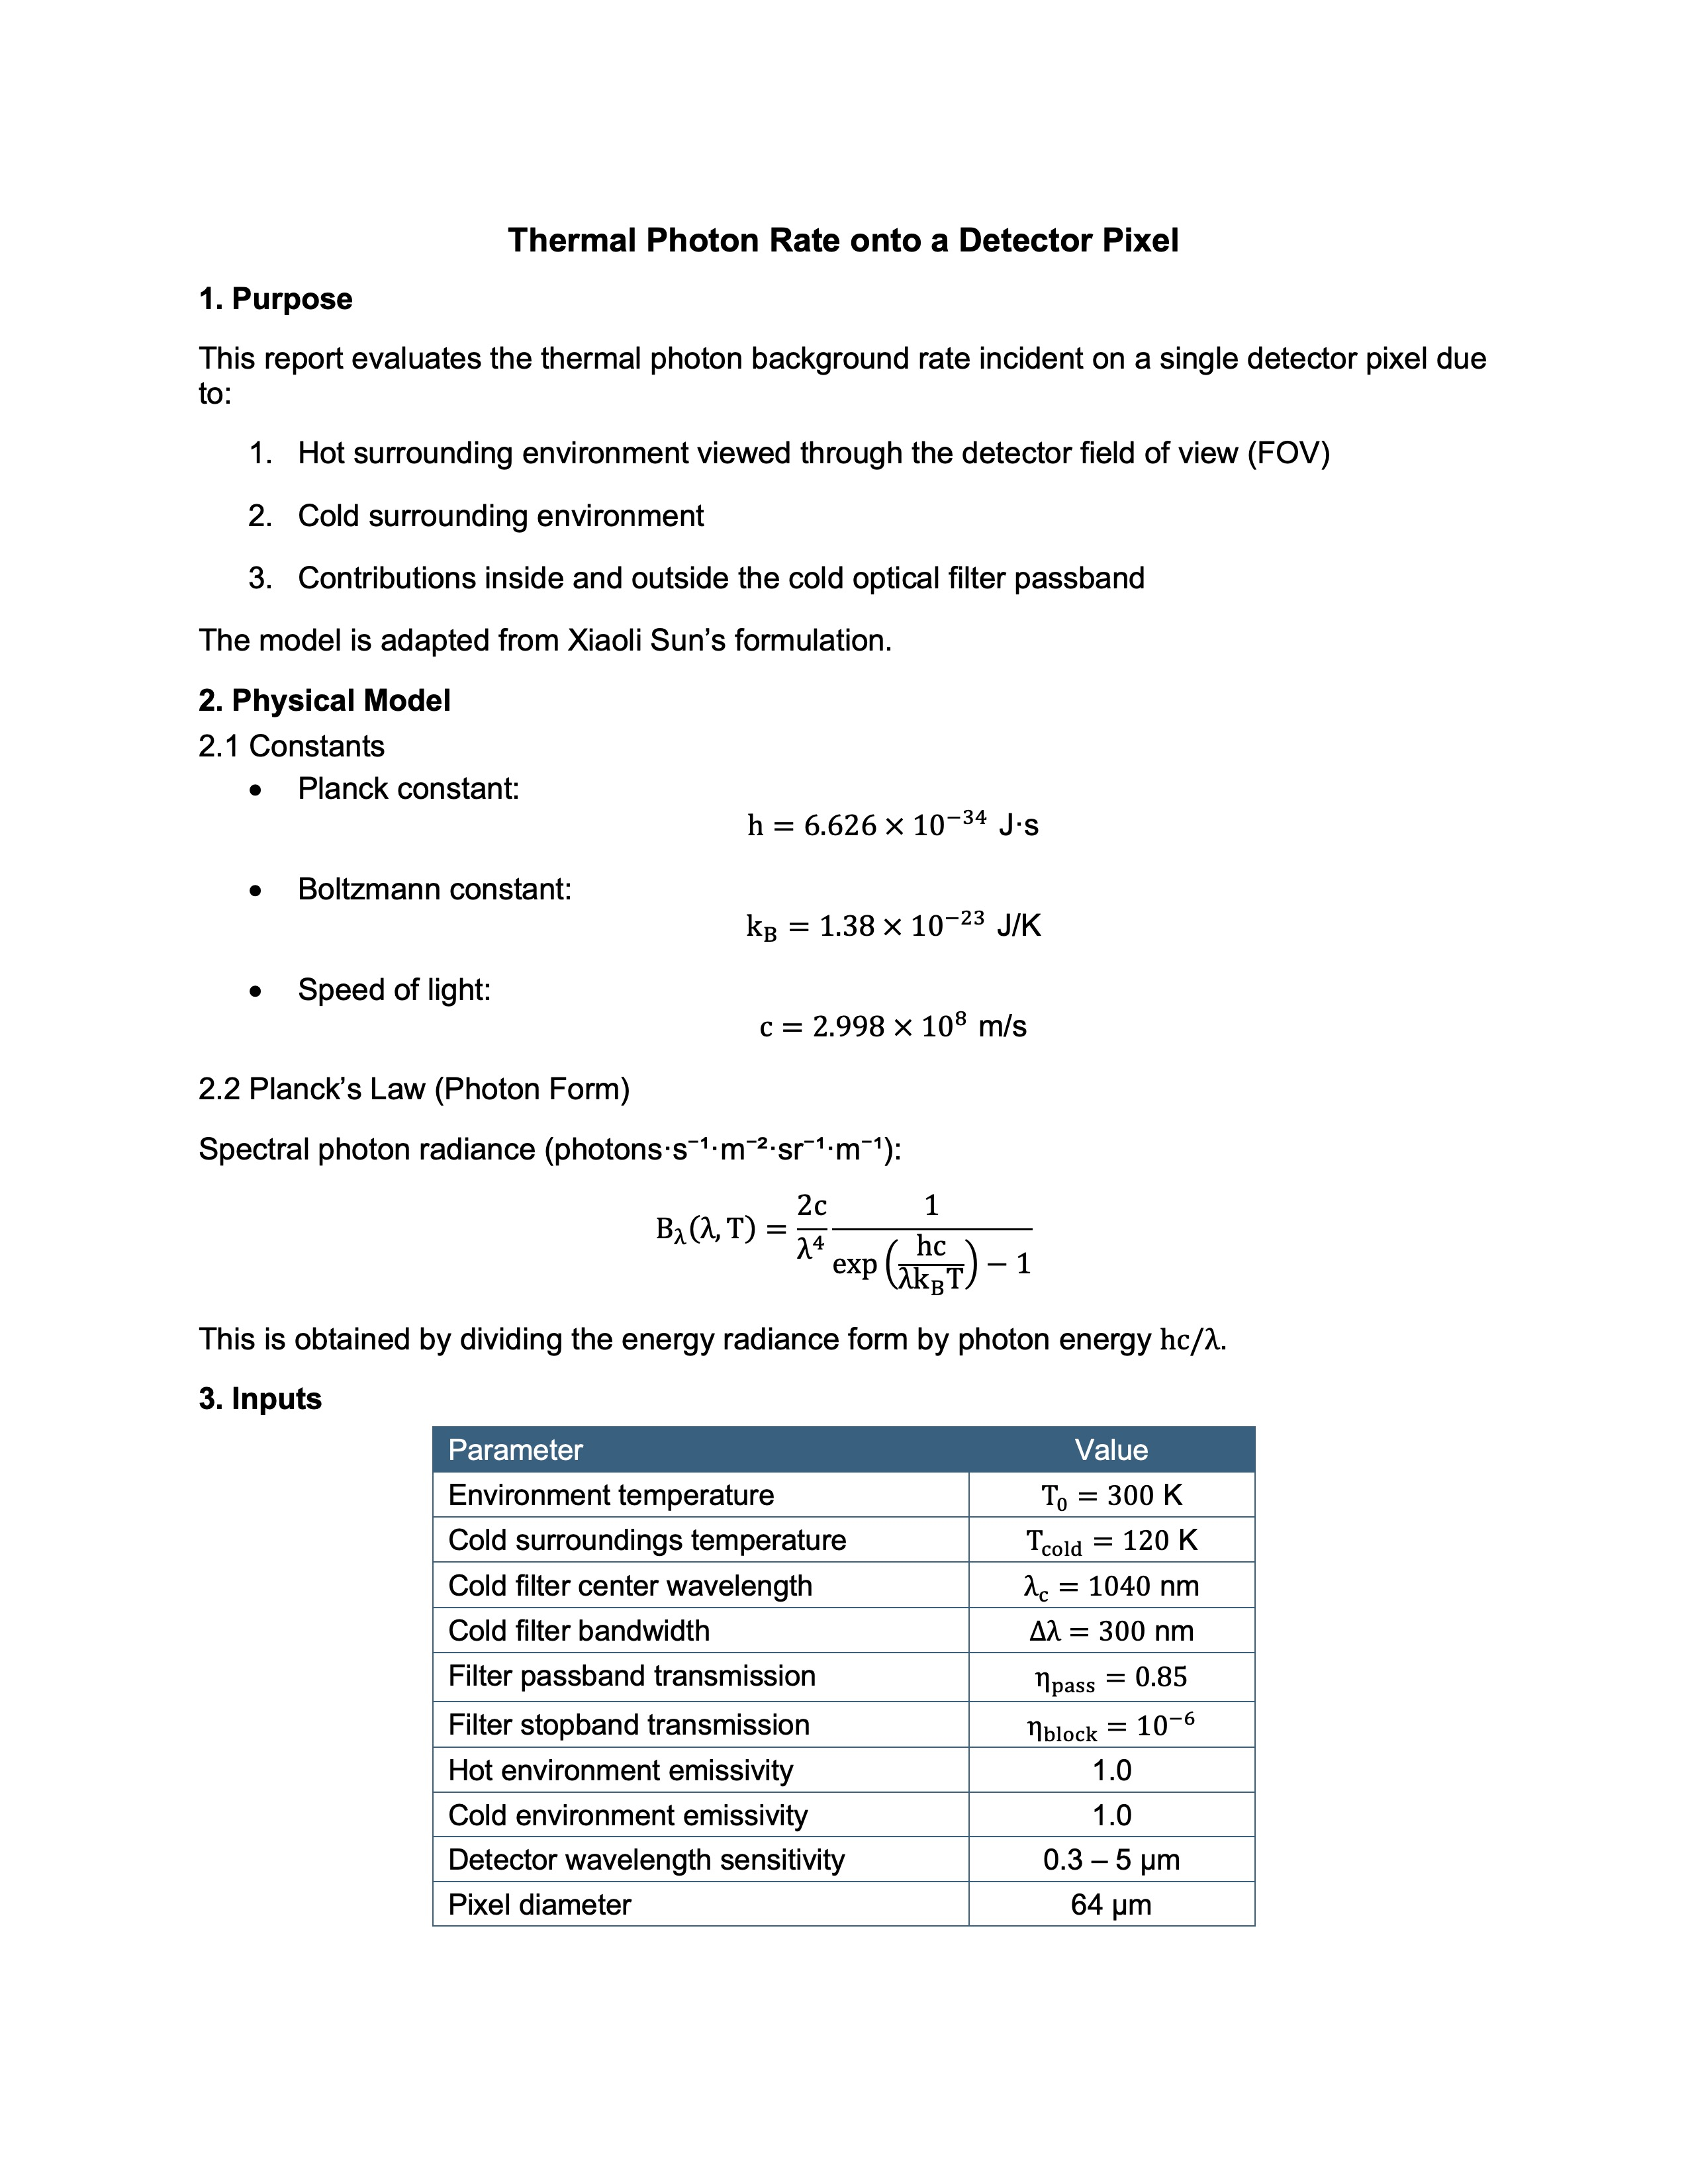

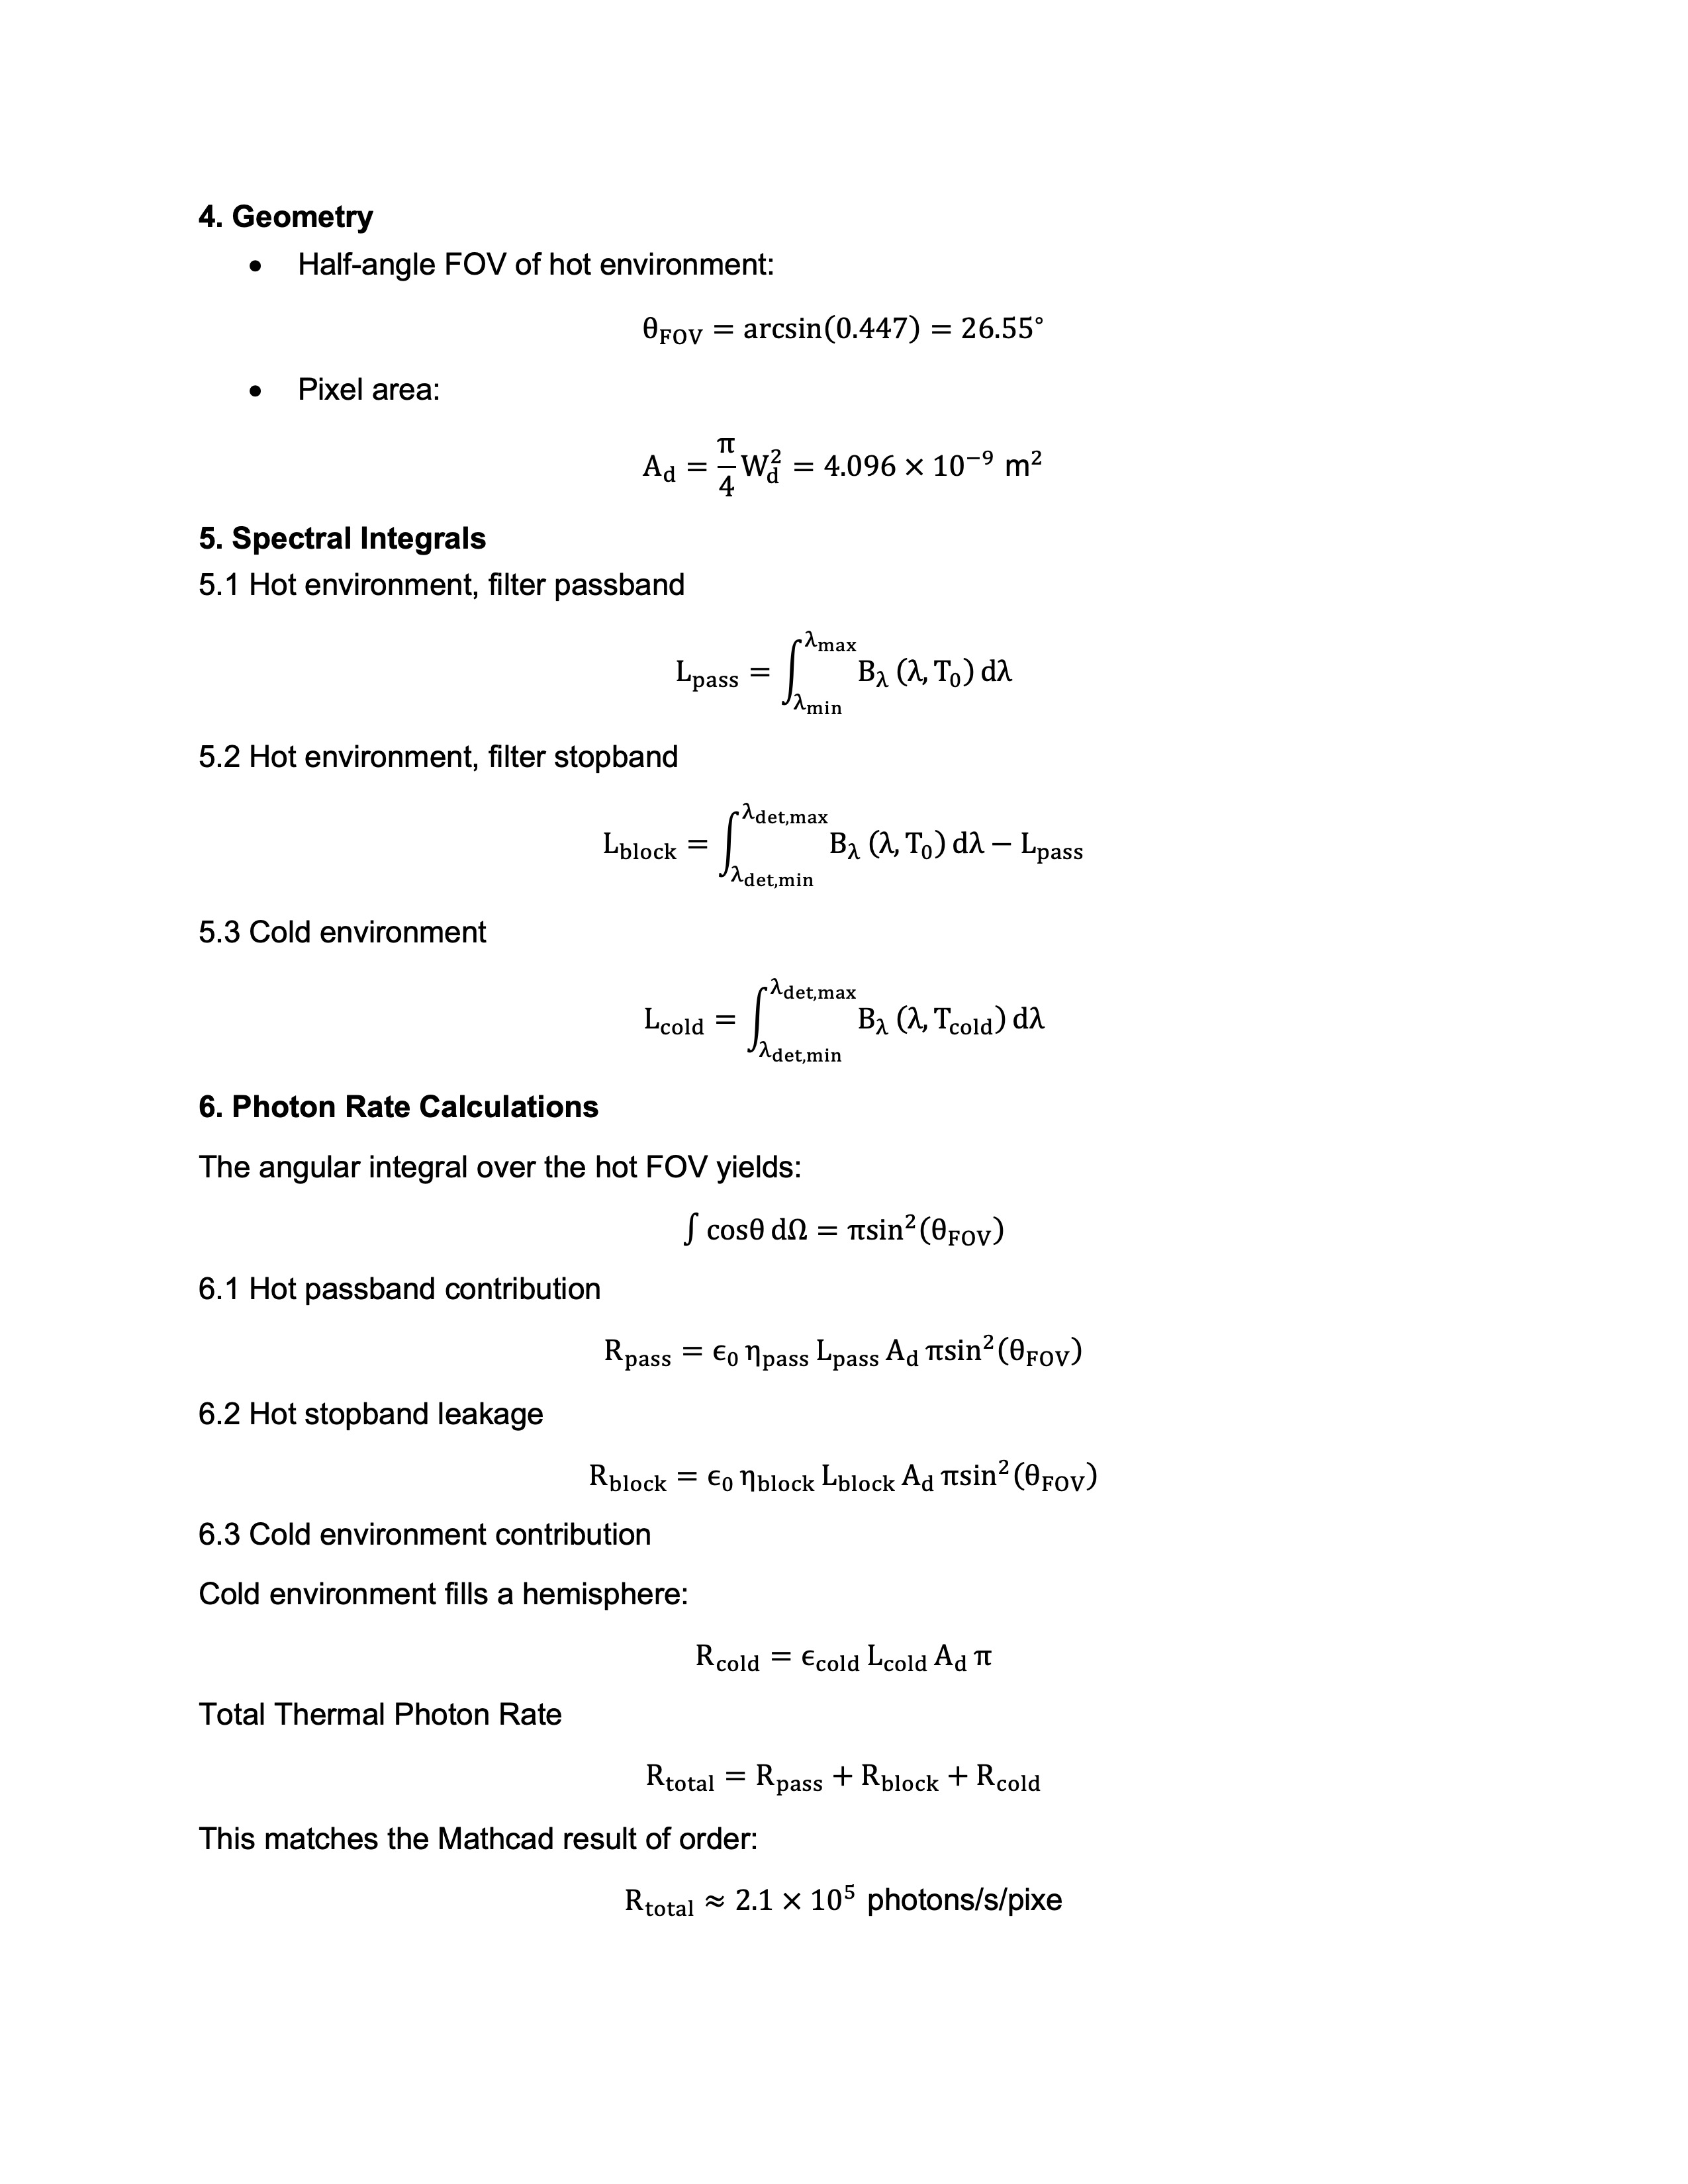

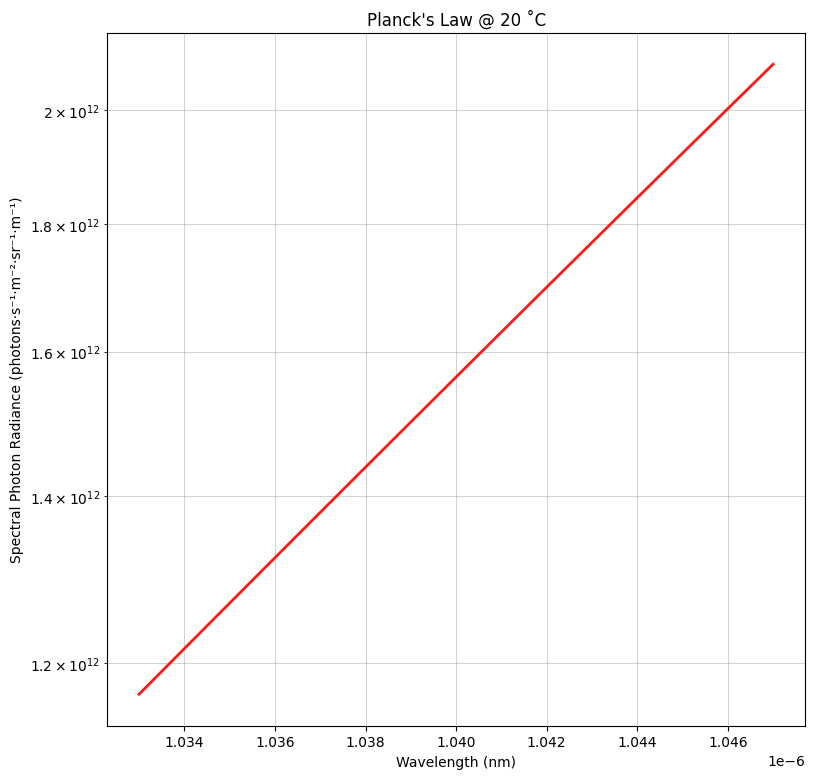

Integrated brightness:
  Cold filter passband, L_pass    : 2.22e+04 /s/m^2
  Cold filter stopband, L_block   : 3.23e+19 /s/m^2
  Hot blackbody phontons, L_hot   : 3.23e+19 /s/m^2
  Cold blackbody phontons, L_cold : 8.28e+12 /s/m^2

Thermal photon rate per pixel:
  Hot passband   : 3.236e-05 photons/s
  Hot stopband   : 6.522e+04 photons/s
  Cold background: 8.364e+04 photons/s
  Total          : 1.489e+05 photons/s


In [9]:
import numpy as np
# import scipy.constants as sc
from scipy.integrate import quad
import matplotlib.pyplot as plt

# Constants
pi = np.pi
h = 6.626e-34        # Planck constant [J·s]
kB = 1.38e-23        # Boltzmann constant [J/K]
c = 2.998e8          # Speed of light [m/s]

# define function for Planck law (photon radiance)
lam = np.linspace(1.033e-6, 1.047e-6, 100)
T = 293

# photons / (s m^2 sr m)
def B_lambda(lam, T):
    return (2 * c / lam**4) / (np.exp(h * c / (lam * kB * T)) - 1)
Spectrum = B_lambda(lam, T)

# Plot
plt.figure(figsize=(9, 9))
plt.plot(lam, Spectrum, linestyle='-', linewidth='2', color='red', alpha=0.9, visible=True, label='Planks Law')
plt.xlabel("Wavelength (nm)")
plt.ylabel("Spectral Photon Radiance (photons·s⁻¹·m⁻²·sr⁻¹·m⁻¹)")
# plt.ylabel("Spectral photon radiance (photons/s/m²/sr/m)")
plt.yscale("log")
plt.title("Planck's Law @ 20 ˚C")
plt.grid(which='both', linestyle='-', linewidth='0.5', color='grey', alpha=0.5, visible=True)
# plt.legend(loc='upper left')
plt.grid(all)
plt.show()

# Inputs
T0 = 293.0           # Environment temperature [K]
Tcold = 120.0        # Cold filter temperature [K]

lambda_c = 1040e-9    # Detector cold filter center wavelength [m]
Delta_lambda = 14e-9 # Detector cold filter wavelength range [m]

eta_pass = 0.85*0.85  # Transmittance of cold filter within passband (power ~ Amplitude^2)
eta_block = 1e-6      # Transmittance of cold filter outside passband

emissivity_hot = 1.0
emissivity_cold = 1.0

lambda_det_min = 0.3e-6   # Detector responsivity min wavelength
lambda_det_max = 5.0e-6   # Detector responsivity max wavelength

Wd = 64e-6           # Detector Pixel diameter [m]
Ad = pi * (Wd/2)**2  # Detector Pixel area [m^2]

# Field of view
theta_FOV = np.arcsin(0.447) # Half angle of hot filed of view of a detector pixel from hot surrounding at T0

# Filter limits
lambda_filter_min = lambda_c - Delta_lambda / 2
lambda_filter_max = lambda_c + Delta_lambda / 2

# Spectral integrals
L_pass, _ = quad(B_lambda, lambda_filter_min, lambda_filter_max, args=(T0,))
L_hot, _ = quad(B_lambda, lambda_det_min, lambda_det_max, args=(T0,))
L_block = L_hot - L_pass
L_cold, _ = quad(B_lambda, lambda_det_min, lambda_det_max, args=(Tcold,))

# Angular factor
angular_hot = pi * np.sin(theta_FOV)**2
angular_cold = pi  # hemisphere

# Photon rates
R_pass = emissivity_hot * eta_pass * L_pass * Ad * angular_hot
R_block = emissivity_hot * eta_block * L_block * Ad * angular_hot
R_cold = emissivity_cold * L_cold * Ad * angular_cold

R_total = R_pass + R_block + R_cold

# Output
print("Integrated brightness:")
print(f"  Cold filter passband, L_pass    : {L_pass:.2e} /s/m^2")
print(f"  Cold filter stopband, L_block   : {L_block:.2e} /s/m^2")
print(f"  Hot blackbody phontons, L_hot   : {L_hot:.2e} /s/m^2")
print(f"  Cold blackbody phontons, L_cold : {L_cold:.2e} /s/m^2")

print() 

print( "Thermal photon rate per pixel:")
print(f"  Hot passband   : {R_pass:.3e} photons/s")
print(f"  Hot stopband   : {R_block:.3e} photons/s")
print(f"  Cold background: {R_cold:.3e} photons/s")
print(f"  Total          : {R_total:.3e} photons/s")
